In [3]:

import pandas as pd
import numpy as np

In [ ]:
##### Read csv file #####

csv_path = '/home/ht21074/Auto_box_apples/Auto_box_apples/'
data_NZ2023 = pd.read_csv(f"{csv_path}data.csv")
data_NZ2024 = pd.read_csv(f"{csv_path}maturity_data_2024NZ2.csv")
data_UK2024 = pd.read_csv(f"{csv_path}maturity_data_2024UK2.csv")

data_UK2024['Cultivar'] = data_UK2024['Cultivar'].replace({'Cox': 'Cox\'s Orange Pippin'})

data_NZ2023 = data_NZ2023.dropna()
data_NZ2024 = data_NZ2024.dropna()
data_UK2024 = data_UK2024.dropna()

data_NZ2023 = data_NZ2023.reset_index()
data_NZ2024 = data_NZ2024.reset_index()
data_UK2024 = data_UK2024.reset_index()

print(data_NZ2023.head())
print(data_NZ2024.head())
print(data_UK2024.head())


   index                    Date Site Cultivar  Number  Firmness1  Firmness2  \
0      0  Tuesday, 28 March 2023  PFR     Fuji     1.0       6.38       6.23   
1      1  Tuesday, 28 March 2023  PFR     Fuji     2.0       7.32       8.84   
2      2  Tuesday, 28 March 2023  PFR     Fuji     3.0       8.02       8.86   
3      3  Tuesday, 28 March 2023  PFR     Fuji     4.0       6.36       7.82   
4      4  Tuesday, 28 March 2023  PFR     Fuji     5.0       8.13       7.38   

    Brix  Starch                                     Image_folder_A  \
0  12.43    50.0  20230328 Fuji PFR orchard early pick\2023-03-2...   
1  14.04    43.0  20230328 Fuji PFR orchard early pick\2023-03-2...   
2  11.53    80.0  20230328 Fuji PFR orchard early pick\2023-03-2...   
3  12.18    63.0  20230328 Fuji PFR orchard early pick\2023-03-2...   
4  12.10    45.0  20230328 Fuji PFR orchard early pick\2023-03-2...   

                                      Image_folder_B  \
0  20230328 Fuji PFR orchard early p

In [5]:
# Convert Firmness of UK2024 to kgf
data_UK2024['Firmness1'] = data_UK2024['Firmness1']/9.80665
data_UK2024['Firmness2'] = data_UK2024['Firmness2']/9.80665

In [6]:
print(data_NZ2023.describe())
print(data_NZ2024.describe())
print(data_UK2024.describe())

             index       Number    Firmness1    Firmness2         Brix  \
count  1701.000000  1701.000000  1701.000000  1701.000000  1701.000000   
mean    857.625514    81.968254     7.705638     7.713445    13.603204   
std     500.603118    79.201464     1.154582     1.152185     1.627579   
min       0.000000     1.000000     3.830000     3.860000     9.260000   
25%     425.000000    27.000000     6.960000     6.940000    12.480000   
50%     850.000000    55.000000     7.590000     7.550000    13.490000   
75%    1297.000000   108.000000     8.320000     8.380000    14.570000   
max    1728.000000   360.000000    15.300000    13.930000    18.860000   

            Starch  
count  1701.000000  
mean     44.013521  
std      29.474343  
min       0.000000  
25%      18.000000  
50%      37.000000  
75%      71.000000  
max     100.000000  
           index  Unnamed: 0       Number    Firmness1    Firmness2  \
count  1567.0000   1567.0000  1567.000000  1567.000000  1567.000000   
me

In [7]:
# Drop index and unnamed columns

data_NZ2023 = data_NZ2023.drop(columns=['index'])
data_NZ2024 = data_NZ2024.drop(columns=['index', 'Unnamed: 0'])
data_UK2024 = data_UK2024.drop(columns=['index', 'Unnamed: 0'])

In [8]:
print("data_NZ", len(data_NZ2023))
print("data_NZ", len(data_NZ2024))
print("data_UK", len(data_UK2024))

data_NZ 1701
data_NZ 1567
data_UK 2656


In [9]:
# Add ID column to data
data_NZ2023["ID"] = data_NZ2023["Cultivar"].astype(str) + "_" + pd.Series(range(1,len(data_NZ2023) + 1)).astype(str)

# Create file name and image number columns

data_NZ2023['Image_folder_A'] = data_NZ2023['Image_folder_A'].str.replace('\\', '/')
split_path = data_NZ2023['Image_folder_A'].str.split('/')
file_name = split_path.str[-1] + '.png'
file_num = file_name.str.split('_')
image_num_A = file_num.str[-1]


data_NZ2023["image_num_A"] = image_num_A
data_NZ2023["image_filename_A"] = file_name 
data_NZ2023['Image_folder_A'] = data_NZ2023['Image_folder_A'] + '/' + file_name

data_NZ2023['Image_folder_B'] = data_NZ2023['Image_folder_B'].str.replace('\\', '/')
split_path = data_NZ2023['Image_folder_B'].str.split('/')
file_name = split_path.str[-1] + '.png'
file_num = file_name.str.split('_')
image_num_B = file_num.str[-1]


data_NZ2023["image_num_B"] = image_num_B
data_NZ2023["image_filename_B"] = file_name
data_NZ2023['Image_folder_B'] = data_NZ2023['Image_folder_B'] + '/' + file_name

data_NZ2023['Image_folder_C'] = data_NZ2023['Image_folder_C'].str.replace('\\', '/')
split_path = data_NZ2023['Image_folder_C'].str.split('/')
file_name = split_path.str[-1] + '.png'
file_num = file_name.str.split('_')
image_num_C = file_num.str[-1]

data_NZ2023["image_num_C"] = image_num_C
data_NZ2023["image_filename_C"] = file_name
data_NZ2023['Image_folder_C'] = data_NZ2023['Image_folder_C'] + '/' + file_name

data_NZ2023['Image_folder_D'] = data_NZ2023['Image_folder_D'].str.replace('\\', '/')
split_path = data_NZ2023['Image_folder_D'].str.split('/')
file_name = split_path.str[-1] + '.png'
file_num = file_name.str.split('_')
image_num_D = file_num.str[-1]

data_NZ2023["image_num_D"] = image_num_D
data_NZ2023["image_filename_D"] = file_name
data_NZ2023['Image_folder_D'] = data_NZ2023['Image_folder_D'] + '/' + file_name

print(data_NZ2023.tail())

           Date             Site  Cultivar  Number  Firmness1  Firmness2  \
1696  4/04/2023  TG - Evenden Rd  Braeburn    43.0       6.73       7.67   
1697  4/04/2023  TG - Evenden Rd  Braeburn    44.0       9.59       9.01   
1698  4/04/2023  TG - Evenden Rd  Braeburn    45.0       7.96       7.71   
1699  4/04/2023  TG - Evenden Rd  Braeburn    46.0       9.68       7.61   
1700  4/04/2023  TG - Evenden Rd  Braeburn    47.0       8.43       7.50   

       Brix  Starch                                     Image_folder_A  \
1696  12.11    43.0  20230404 Braeburn TG/2023-04-04_033/2023-04-04...   
1697  14.33    83.0  20230404 Braeburn TG/2023-04-04_033/2023-04-04...   
1698  12.27    80.0  20230404 Braeburn TG/2023-04-04_033/2023-04-04...   
1699  12.77    27.0  20230404 Braeburn TG/2023-04-04_033/2023-04-04...   
1700  12.88    35.0  20230404 Braeburn TG/2023-04-04_033/2023-04-04...   

                                         Image_folder_B  ...  \
1696  20230404 Braeburn TG/2023-04

In [10]:
# Add ID column to data 

data_NZ2024["ID"] = data_NZ2024["Cultivar"].astype(str) + "_" + pd.Series(range(1,len(data_NZ2024) + 1)).astype(str)

# Create file name and image number columns

split_path = data_NZ2024['Image_folder_A'].str.split('/')
file_name = split_path.str[-1]
file_num = file_name.str.split('_')
img_num_1 = file_num.str[-1]
image_num_A = img_num_1.str.replace('.png','')

data_NZ2024["image_num_A"] = image_num_A
data_NZ2024["image_filename_A"] = file_name

split_path = data_NZ2024['Image_folder_B'].str.split('/')
file_name = split_path.str[-1]
file_num = file_name.str.split('_')
img_num_1 = file_num.str[-1]
image_num_B = img_num_1.str.replace('.png','')

data_NZ2024["image_num_B"] = image_num_B
data_NZ2024["image_filename_B"] = file_name

split_path = data_NZ2024['Image_folder_C'].str.split('/')
file_name = split_path.str[-1]
file_num = file_name.str.split('_')
img_num_1 = file_num.str[-1]
image_num_C = img_num_1.str.replace('.png','')

data_NZ2024["image_num_C"] = image_num_C
data_NZ2024["image_filename_C"] = file_name

split_path = data_NZ2024['Image_folder_D'].str.split('/')
file_name = split_path.str[-1]
file_num = file_name.str.split('_')
img_num_1 = file_num.str[-1]
image_num_D = img_num_1.str.replace('.png','')

data_NZ2024["image_num_D"] = image_num_D
data_NZ2024["image_filename_D"] = file_name

print(data_NZ2024.tail())


           Date  Number    Site  Cultivar  Firmness1  Firmness2   Brix  \
1562  12-Apr-24     116  Nelson  Braeburn       8.13       8.97  12.55   
1563  12-Apr-24     117  Nelson  Braeburn       8.27       8.56  12.56   
1564  12-Apr-24     118  Nelson  Braeburn       8.46       8.77  12.64   
1565  12-Apr-24     119  Nelson  Braeburn       8.65       8.84  14.10   
1566  12-Apr-24     120  Nelson  Braeburn      10.51       9.64  13.14   

      Starch                                     Image_folder_A  \
1562      66  20240412 Braeburn Nelson/2024-04-12_079/2024-0...   
1563      33  20240412 Braeburn Nelson/2024-04-12_079/2024-0...   
1564      45  20240412 Braeburn Nelson/2024-04-12_079/2024-0...   
1565      40  20240412 Braeburn Nelson/2024-04-12_079/2024-0...   
1566      45  20240412 Braeburn Nelson/2024-04-12_079/2024-0...   

                                         Image_folder_B  ...  \
1562  20240412 Braeburn Nelson/2024-04-12_080/2024-0...  ...   
1563  20240412 Braeburn 

In [11]:
# Add ID column to data
data_UK2024["ID"] = data_UK2024["Cultivar"].astype(str) + "_" + pd.Series(range(1,len(data_UK2024) + 1)).astype(str)

# Create file name and image number columns

split_path = data_UK2024['Image_folder_A'].str.split('/')
file_name = split_path.str[-1]
file_num = file_name.str.split('_')
img_num_1 = file_num.str[-1]
image_num_A = img_num_1.str.replace('.png','')

data_UK2024["image_num"] = image_num_A
data_UK2024["image_filename_A"] = file_name

split_path = data_UK2024['Image_folder_B'].str.split('/')
file_name = split_path.str[-1]
file_num = file_name.str.split('_')
img_num_1 = file_num.str[-1]
image_num_B = img_num_1.str.replace('.png','')

data_UK2024["image_num_B"] = image_num_B
data_UK2024["image_filename_B"] = file_name

split_path = data_UK2024['Image_folder_C'].str.split('/')
file_name = split_path.str[-1]
file_num = file_name.str.split('_')
img_num_1 = file_num.str[-1]
image_num_C = img_num_1.str.replace('.png','')

data_UK2024["image_num_C"] = image_num_C
data_UK2024["image_filename_C"] = file_name

split_path = data_UK2024['Image_folder_D'].str.split('/')
file_name = split_path.str[-1]
file_num = file_name.str.split('_')
img_num_1 = file_num.str[-1]
image_num_D = img_num_1.str.replace('.png','')

data_UK2024["image_num_D"] = image_num_D
data_UK2024["image_filename_D"] = file_name

print(data_UK2024.tail())


      Number Tree  Cultivar  Brix  Starch  Firmness1  Firmness2 Site  \
2651     206   EM  Braeburn  12.4      44   9.806611   8.885297   EM   
2652     207   EM  Braeburn  10.5      89   7.502664   8.401136   EM   
2653     208   EM  Braeburn  11.1      69   9.155624   7.834582   EM   
2654     209   EM  Braeburn  11.2      67   8.478430   7.799096   EM   
2655     210   EM  Braeburn  11.7      67   9.299710   9.390771   EM   

           Date                Image_folder_A  ...  \
2651  23-Oct-24  20241023GDFuji/1551/1551.png  ...   
2652  23-Oct-24  20241023GDFuji/1551/1551.png  ...   
2653  23-Oct-24  20241023GDFuji/1551/1551.png  ...   
2654  23-Oct-24  20241023GDFuji/1551/1551.png  ...   
2655  23-Oct-24  20241023GDFuji/1551/1551.png  ...   

                    Image_folder_D             ID image_num image_filename_A  \
2651  20241023GDFuji/1554/1554.png  Braeburn_2652      1551         1551.png   
2652  20241023GDFuji/1554/1554.png  Braeburn_2653      1551         1551.png   
26

In [12]:
pd.options.display.max_colwidth = None
print(data_NZ2023['Image_folder_A'][0])
print(data_NZ2023['Image_folder_B'][0])
print(data_NZ2023['Image_folder_C'][0])
print(data_NZ2023['Image_folder_D'][0])


20230328 Fuji PFR orchard early pick/2023-03-28_002/2023-03-28_002.png
20230328 Fuji PFR orchard early pick/2023-03-28_003/2023-03-28_003.png
20230328 Fuji PFR orchard early pick/2023-03-28_004/2023-03-28_004.png
20230328 Fuji PFR orchard early pick/2023-03-28_005/2023-03-28_005.png


In [13]:
# Calculate average firmness
data_NZ2023["Avg_firmness"] = data_NZ2023[["Firmness1", "Firmness2"]].mean(axis=1)
data_NZ2024["Avg_firmness"] = data_NZ2024[["Firmness1", "Firmness2"]].mean(axis=1)
data_UK2024["Avg_firmness"] = data_UK2024[["Firmness1", "Firmness2"]].mean(axis=1)

In [14]:
# Create Streif column
# Reset Starch from percentages to starch pattern index values

choices = [
        1, # Starch > 95,
        2, #Starch <= 95 & Starch >= 91,
        3, #Starch < 91 & Starch >= 86,
        4, #Starch < 86 & Starch >= 79 ,
        5, #Starch < 79 & Starch >= 71 ,
        6, #Starch < 71 & Starch >= 66 ,
        7, #Starch < 66 & Starch >= 56 ,
        8, #Starch < 56 & Starch >= 42 ,
        9, #Starch < 42 & Starch >= 20 ,
        10, #Starch < 20 & Starch >= 0 
]

conditions = [
    (data_NZ2023['Starch'] > 95),
    (data_NZ2023['Starch'] <= 95) & (data_NZ2023['Starch'] >= 91),
    (data_NZ2023['Starch'] < 91) & (data_NZ2023['Starch'] >= 86),
    (data_NZ2023['Starch'] < 86) & (data_NZ2023['Starch'] >= 79),
    (data_NZ2023['Starch'] < 79) & (data_NZ2023['Starch'] >= 71),
    (data_NZ2023['Starch'] < 71) & (data_NZ2023['Starch'] >= 66),
    (data_NZ2023['Starch'] < 66) & (data_NZ2023['Starch'] >= 56),
    (data_NZ2023['Starch'] < 56) & (data_NZ2023['Starch'] >= 42),
    (data_NZ2023['Starch'] < 42) & (data_NZ2023['Starch'] >= 20),
    (data_NZ2023['Starch'] < 20) & (data_NZ2023['Starch'] >= 0)
]


       
data_NZ2023['Starch2'] = np.select(conditions, choices, default=np.nan)
data_NZ2023['Streif'] = data_NZ2023["Avg_firmness"]/data_NZ2023["Brix"]*data_NZ2023['Starch2']


conditions = [
    (data_NZ2024['Starch'] > 95),
    (data_NZ2024['Starch'] <= 95) & (data_NZ2024['Starch'] >= 91),
    (data_NZ2024['Starch'] < 91) & (data_NZ2024['Starch'] >= 86),
    (data_NZ2024['Starch'] < 86) & (data_NZ2024['Starch'] >= 79),
    (data_NZ2024['Starch'] < 79) & (data_NZ2024['Starch'] >= 71),
    (data_NZ2024['Starch'] < 71) & (data_NZ2024['Starch'] >= 66),
    (data_NZ2024['Starch'] < 66) & (data_NZ2024['Starch'] >= 56),
    (data_NZ2024['Starch'] < 56) & (data_NZ2024['Starch'] >= 42),
    (data_NZ2024['Starch'] < 42) & (data_NZ2024['Starch'] >= 20),
    (data_NZ2024['Starch'] < 20) & (data_NZ2024['Starch'] >= 0)
]

data_NZ2024['Starch2'] = np.select(conditions, choices, default=np.nan)
data_NZ2024['Streif'] = data_NZ2024["Avg_firmness"]/data_NZ2024["Brix"]*data_NZ2024['Starch2']


conditions = [
    (data_UK2024['Starch'] > 95),
    (data_UK2024['Starch'] <= 95) & (data_UK2024['Starch'] >= 91),
    (data_UK2024['Starch'] < 91) & (data_UK2024['Starch'] >= 86),
    (data_UK2024['Starch'] < 86) & (data_UK2024['Starch'] >= 79),
    (data_UK2024['Starch'] < 79) & (data_UK2024['Starch'] >= 71),
    (data_UK2024['Starch'] < 71) & (data_UK2024['Starch'] >= 66),
    (data_UK2024['Starch'] < 66) & (data_UK2024['Starch'] >= 56),
    (data_UK2024['Starch'] < 56) & (data_UK2024['Starch'] >= 42),
    (data_UK2024['Starch'] < 42) & (data_UK2024['Starch'] >= 20),
    (data_UK2024['Starch'] < 20) & (data_UK2024['Starch'] >= 0)
]
       
data_UK2024['Starch2'] = np.select(conditions, choices, default=np.nan)
data_UK2024['Streif'] = data_UK2024["Avg_firmness"]/data_UK2024["Brix"]*data_UK2024['Starch2']

print(data_NZ2023.tail())
print(data_NZ2024.tail())
print(data_UK2024.tail())

           Date             Site  Cultivar  Number  Firmness1  Firmness2  \
1696  4/04/2023  TG - Evenden Rd  Braeburn    43.0       6.73       7.67   
1697  4/04/2023  TG - Evenden Rd  Braeburn    44.0       9.59       9.01   
1698  4/04/2023  TG - Evenden Rd  Braeburn    45.0       7.96       7.71   
1699  4/04/2023  TG - Evenden Rd  Braeburn    46.0       9.68       7.61   
1700  4/04/2023  TG - Evenden Rd  Braeburn    47.0       8.43       7.50   

       Brix  Starch                                          Image_folder_A  \
1696  12.11    43.0  20230404 Braeburn TG/2023-04-04_033/2023-04-04_033.png   
1697  14.33    83.0  20230404 Braeburn TG/2023-04-04_033/2023-04-04_033.png   
1698  12.27    80.0  20230404 Braeburn TG/2023-04-04_033/2023-04-04_033.png   
1699  12.77    27.0  20230404 Braeburn TG/2023-04-04_033/2023-04-04_033.png   
1700  12.88    35.0  20230404 Braeburn TG/2023-04-04_033/2023-04-04_033.png   

                                              Image_folder_B  ...  \

In [15]:
# Check for duplicate rows
duplicates = data_NZ2023.duplicated(subset=['Date', 'Site', 'Cultivar', 'Firmness1', 'Firmness2', 'Brix', 'Starch'], keep = False)

duplicates_NZ2023 = data_NZ2023[duplicates]

print('duplicates_NZ2023')
print(duplicates_NZ2023)


duplicates = data_NZ2024.duplicated(subset=['Date', 'Site', 'Cultivar', 'Firmness1', 'Firmness2', 'Brix', 'Starch'], keep = False)

duplicates_NZ2024 = data_NZ2024[duplicates]

print('duplicates_NZ2024')
print(duplicates_NZ2024)
# duplicates_NZ.to_csv('duplicates_NZ.csv')

duplicates_UK = data_UK2024.duplicated(subset=['Date', 'Site', 'Cultivar', 'Firmness1', 'Firmness2', 'Brix', 'Starch'], keep = False)

duplicates_UK22024 = data_UK2024[duplicates_UK]

print('duplicates_UK2024')
print(duplicates_UK22024)



duplicates_NZ2023
Empty DataFrame
Columns: [Date, Site, Cultivar, Number, Firmness1, Firmness2, Brix, Starch, Image_folder_A, Image_folder_B, Image_folder_C, Image_folder_D, ID, image_num_A, image_filename_A, image_num_B, image_filename_B, image_num_C, image_filename_C, image_num_D, image_filename_D, Avg_firmness, Starch2, Streif]
Index: []

[0 rows x 24 columns]
duplicates_NZ2024
           Date  Number      Site  Cultivar  Firmness1  Firmness2   Brix  \
271    8-Mar-24      97  PFR FOPs      Gala       7.92       7.50  11.41   
272    8-Mar-24      97  PFR FOPs      Gala       7.92       7.50  11.41   
273    8-Mar-24      98  PFR FOPs      Gala       7.86       7.80  10.93   
274    8-Mar-24      98  PFR FOPs      Gala       7.86       7.80  10.93   
275    8-Mar-24      99  PFR FOPs      Gala       8.02       7.38  11.71   
...         ...     ...       ...       ...        ...        ...    ...   
1538  12-Apr-24      96    Nelson  Braeburn      10.05       9.06  16.32   
1539  12

In [16]:
# keep only the first row of duplicated rows

data_NZ_unique = data_NZ2024.drop_duplicates(subset=['Date', 'Site', 'Cultivar', 'Firmness1', 'Firmness2', 'Brix', 'Starch'], keep='first')

data_NZ2024 = data_NZ_unique.reset_index()

print(data_NZ2024)


data_UK_unique = data_UK2024.drop_duplicates(subset=['Date', 'Site', 'Cultivar', 'Firmness1', 'Firmness2', 'Brix', 'Starch'], keep='first')

data_UK2024 = data_UK_unique.reset_index()

print(data_UK2024)



      index       Date  Number      Site  Cultivar  Firmness1  Firmness2  \
0         0   7-Mar-24       1  PFR FOPs      Gala       7.75       7.44   
1         1   7-Mar-24       2  PFR FOPs      Gala       8.10       7.42   
2         2   7-Mar-24       3  PFR FOPs      Gala       8.02       7.09   
3         3   7-Mar-24       4  PFR FOPs      Gala       7.53       7.07   
4         4   7-Mar-24       5  PFR FOPs      Gala       7.30       7.11   
...     ...        ...     ...       ...       ...        ...        ...   
1404   1562  12-Apr-24     116    Nelson  Braeburn       8.13       8.97   
1405   1563  12-Apr-24     117    Nelson  Braeburn       8.27       8.56   
1406   1564  12-Apr-24     118    Nelson  Braeburn       8.46       8.77   
1407   1565  12-Apr-24     119    Nelson  Braeburn       8.65       8.84   
1408   1566  12-Apr-24     120    Nelson  Braeburn      10.51       9.64   

       Brix  Starch  \
0     12.69      32   
1     12.53      22   
2     11.80      2

In [17]:
# Check for duplicates again
duplicates_remaining = data_NZ_unique.duplicated(subset=['Date', 'Site', 'Cultivar', 'Firmness1', 'Firmness2', 'Brix', 'Starch'], keep=False)
print(data_NZ_unique[duplicates_remaining])  # returns an empty DataFrame

# Check for duplicates again
duplicates_remaining = data_UK_unique.duplicated(subset=['Date', 'Site', 'Cultivar', 'Firmness1', 'Firmness2', 'Brix', 'Starch'], keep=False)
print(data_UK_unique[duplicates_remaining])  # returns an empty DataFrame

Empty DataFrame
Columns: [Date, Number, Site, Cultivar, Firmness1, Firmness2, Brix, Starch, Image_folder_A, Image_folder_B, Image_folder_C, Image_folder_D, ID, image_num_A, image_filename_A, image_num_B, image_filename_B, image_num_C, image_filename_C, image_num_D, image_filename_D, Avg_firmness, Starch2, Streif]
Index: []

[0 rows x 24 columns]
Empty DataFrame
Columns: [Number, Tree, Cultivar, Brix, Starch, Firmness1, Firmness2, Site, Date, Image_folder_A, Image_folder_B, Image_folder_C, Image_folder_D, ID, image_num, image_filename_A, image_num_B, image_filename_B, image_num_C, image_filename_C, image_num_D, image_filename_D, Avg_firmness, Starch2, Streif]
Index: []

[0 rows x 25 columns]


In [18]:
save_file_path = '/home/ht21074/Auto_box_apples/Auto_box_apples/Source_folder/csv_files/All_data_csv/'

data_NZ2023.to_csv(f'{save_file_path}data_NZ2023.csv', index=False)
data_NZ2024.to_csv(f'{save_file_path}data_NZ2024.csv', index=False)
data_UK2024.to_csv(f'{save_file_path}data_UK2024.csv', index=False)

In [19]:
print(data_NZ2023.describe())

            Number    Firmness1    Firmness2         Brix       Starch  \
count  1701.000000  1701.000000  1701.000000  1701.000000  1701.000000   
mean     81.968254     7.705638     7.713445    13.603204    44.013521   
std      79.201464     1.154582     1.152185     1.627579    29.474343   
min       1.000000     3.830000     3.860000     9.260000     0.000000   
25%      27.000000     6.960000     6.940000    12.480000    18.000000   
50%      55.000000     7.590000     7.550000    13.490000    37.000000   
75%     108.000000     8.320000     8.380000    14.570000    71.000000   
max     360.000000    15.300000    13.930000    18.860000   100.000000   

       Avg_firmness      Starch2       Streif  
count   1701.000000  1701.000000  1701.000000  
mean       7.709541     7.479718     4.119974  
std        1.065978     2.711040     1.385207  
min        4.130000     1.000000     0.574140  
25%        7.015000     5.000000     3.251765  
50%        7.580000     9.000000     4.471963

## Exploratory analysis ##


In [1]:
import pandas as pd
save_file_path = '/home/ht21074/Auto_box_apples/Auto_box_apples/Source_folder/csv_files/All_data_csv/'

data_NZ2023 = pd.read_csv(f'{save_file_path}data_NZ2023.csv')
data_NZ2024 = pd.read_csv(f'{save_file_path}data_NZ2024.csv')
data_UK2024 = pd.read_csv(f'{save_file_path}data_UK2024.csv')

In [2]:
print(data_NZ2023.head(2))
print(data_NZ2024.head(2))
print(data_UK2024.head(2))

                     Date Site Cultivar  Number  Firmness1  Firmness2   Brix  \
0  Tuesday, 28 March 2023  PFR     Fuji     1.0       6.38       6.23  12.43   
1  Tuesday, 28 March 2023  PFR     Fuji     2.0       7.32       8.84  14.04   

   Starch                                     Image_folder_A  \
0    50.0  20230328 Fuji PFR orchard early pick/2023-03-2...   
1    43.0  20230328 Fuji PFR orchard early pick/2023-03-2...   

                                      Image_folder_B  ...    image_filename_A  \
0  20230328 Fuji PFR orchard early pick/2023-03-2...  ...  2023-03-28_002.png   
1  20230328 Fuji PFR orchard early pick/2023-03-2...  ...  2023-03-28_002.png   

  image_num_B    image_filename_B image_num_C    image_filename_C image_num_D  \
0     003.png  2023-03-28_003.png     004.png  2023-03-28_004.png     005.png   
1     003.png  2023-03-28_003.png     004.png  2023-03-28_004.png     005.png   

     image_filename_D Avg_firmness Starch2    Streif  
0  2023-03-28_005.png  

In [3]:
print(data_NZ2023.describe())
print(data_NZ2024.describe())
print(data_UK2024.describe())

            Number    Firmness1    Firmness2         Brix       Starch  \
count  1701.000000  1701.000000  1701.000000  1701.000000  1701.000000   
mean     81.968254     7.705638     7.713445    13.603204    44.013521   
std      79.201464     1.154582     1.152185     1.627579    29.474343   
min       1.000000     3.830000     3.860000     9.260000     0.000000   
25%      27.000000     6.960000     6.940000    12.480000    18.000000   
50%      55.000000     7.590000     7.550000    13.490000    37.000000   
75%     108.000000     8.320000     8.380000    14.570000    71.000000   
max     360.000000    15.300000    13.930000    18.860000   100.000000   

       Avg_firmness      Starch2       Streif  
count   1701.000000  1701.000000  1701.000000  
mean       7.709541     7.479718     4.119974  
std        1.065978     2.711040     1.385207  
min        4.130000     1.000000     0.574140  
25%        7.015000     5.000000     3.251765  
50%        7.580000     9.000000     4.471963

# Check number of fruit in each year

In [23]:
print(data_NZ2023.groupby('Cultivar').describe())
print(data_NZ2024.groupby('Cultivar').describe())
print(data_UK2024.groupby('Cultivar').describe())

                    Number                                                   \
                     count        mean        std  min    25%   50%     75%   
Cultivar                                                                      
Braeburn              47.0   24.000000  13.711309  1.0  12.50  24.0   35.50   
Cox's Orange Pippin  248.0   81.318548  55.304378  1.0  34.75  67.5  128.25   
Fuji                 811.0  114.094945  95.880968  1.0  41.00  82.0  159.00   
Gala                 463.0   36.336933  24.215458  1.0  17.00  34.0   51.00   
Golden Delicious     132.0   66.500000  38.249183  1.0  33.75  66.5   99.25   

                           Firmness1            ... Starch2       Streif  \
                       max     count      mean  ...     75%   max  count   
Cultivar                                        ...                        
Braeburn              47.0      47.0  8.139149  ...     9.0  10.0   47.0   
Cox's Orange Pippin  190.0     248.0  8.387419  ...     8.0  10

# Check number of images per cultivar in each year

In [24]:
print(data_NZ2023.head())
print(data_NZ2024.head())
print(data_UK2024.head())

                     Date Site Cultivar  Number  Firmness1  Firmness2   Brix  \
0  Tuesday, 28 March 2023  PFR     Fuji     1.0       6.38       6.23  12.43   
1  Tuesday, 28 March 2023  PFR     Fuji     2.0       7.32       8.84  14.04   
2  Tuesday, 28 March 2023  PFR     Fuji     3.0       8.02       8.86  11.53   
3  Tuesday, 28 March 2023  PFR     Fuji     4.0       6.36       7.82  12.18   
4  Tuesday, 28 March 2023  PFR     Fuji     5.0       8.13       7.38  12.10   

   Starch  \
0    50.0   
1    43.0   
2    80.0   
3    63.0   
4    45.0   

                                                           Image_folder_A  \
0  20230328 Fuji PFR orchard early pick/2023-03-28_002/2023-03-28_002.png   
1  20230328 Fuji PFR orchard early pick/2023-03-28_002/2023-03-28_002.png   
2  20230328 Fuji PFR orchard early pick/2023-03-28_002/2023-03-28_002.png   
3  20230328 Fuji PFR orchard early pick/2023-03-28_002/2023-03-28_002.png   
4  20230328 Fuji PFR orchard early pick/2023-03-28_002/

In [25]:
unique_img_NZ2023_A = data_NZ2023.drop_duplicates(subset = 'image_filename_A')
unique_img_NZ2024_A = data_NZ2024.drop_duplicates(subset = 'image_filename_A')
unique_img_UK2024_A = data_UK2024.drop_duplicates(subset = 'image_filename_A')

unique_img_NZ2023_B = data_NZ2023.drop_duplicates(subset = 'image_filename_B')
unique_img_NZ2024_B = data_NZ2024.drop_duplicates(subset = 'image_filename_B')
unique_img_UK2024_B = data_UK2024.drop_duplicates(subset = 'image_filename_B')

unique_img_NZ2023_C = data_NZ2023.drop_duplicates(subset = 'image_filename_C')
unique_img_NZ2024_C = data_NZ2024.drop_duplicates(subset = 'image_filename_C')
unique_img_UK2024_C = data_UK2024.drop_duplicates(subset = 'image_filename_C')

unique_img_NZ2023_D = data_NZ2023.drop_duplicates(subset = 'image_filename_D')
unique_img_NZ2024_D = data_NZ2024.drop_duplicates(subset = 'image_filename_D')
unique_img_UK2024_D = data_UK2024.drop_duplicates(subset = 'image_filename_D')

unique_img_NZ2023 = pd.concat([unique_img_NZ2023_A, unique_img_NZ2023_B, unique_img_NZ2023_C, unique_img_NZ2023_D], ignore_index=True)
unique_img_NZ2024 = pd.concat([unique_img_NZ2024_A, unique_img_NZ2024_B, unique_img_NZ2024_C, unique_img_NZ2024_D], ignore_index=True)
unique_img_UK2024 = pd.concat([unique_img_UK2024_A, unique_img_UK2024_B, unique_img_UK2024_C, unique_img_UK2024_D], ignore_index=True)

print(unique_img_NZ2023.groupby('Cultivar').describe())
print(unique_img_NZ2024.groupby('Cultivar').describe())
print(unique_img_UK2024.groupby('Cultivar').describe())



                    Number                                                 \
                     count        mean        std  min   25%   50%    75%   
Cultivar                                                                    
Braeburn              32.0   22.000000  13.967705  1.0  11.5  22.0   32.5   
Cox's Orange Pippin  180.0   69.288889  53.920124  1.0  25.0  54.0  108.0   
Fuji                 472.0  105.067797  91.425672  1.0  37.0  78.0  145.0   
Gala                 356.0   34.168539  24.097097  1.0  13.0  31.0   49.0   
Golden Delicious     104.0   57.038462  37.507261  1.0  25.0  51.0   89.0   

                           Firmness1            ... Starch2       Streif  \
                       max     count      mean  ...     75%   max  count   
Cultivar                                        ...                        
Braeburn              43.0      32.0  7.760000  ...     8.0   8.0   32.0   
Cox's Orange Pippin  186.0     180.0  8.434444  ...     8.0  10.0  180.0   
Fuj

In [26]:
import matplotlib.pyplot as plt

data_NZ2023['source'] = 'NZ2023'
data_NZ2024['source'] = 'NZ2024'
data_UK2024['source'] = 'UK2024'

data_all = pd.concat([data_NZ2023, data_NZ2024, data_UK2024])

print(data_all.head())




                     Date Site Cultivar  Number  Firmness1  Firmness2   Brix  \
0  Tuesday, 28 March 2023  PFR     Fuji     1.0       6.38       6.23  12.43   
1  Tuesday, 28 March 2023  PFR     Fuji     2.0       7.32       8.84  14.04   
2  Tuesday, 28 March 2023  PFR     Fuji     3.0       8.02       8.86  11.53   
3  Tuesday, 28 March 2023  PFR     Fuji     4.0       6.36       7.82  12.18   
4  Tuesday, 28 March 2023  PFR     Fuji     5.0       8.13       7.38  12.10   

   Starch  \
0    50.0   
1    43.0   
2    80.0   
3    63.0   
4    45.0   

                                                           Image_folder_A  \
0  20230328 Fuji PFR orchard early pick/2023-03-28_002/2023-03-28_002.png   
1  20230328 Fuji PFR orchard early pick/2023-03-28_002/2023-03-28_002.png   
2  20230328 Fuji PFR orchard early pick/2023-03-28_002/2023-03-28_002.png   
3  20230328 Fuji PFR orchard early pick/2023-03-28_002/2023-03-28_002.png   
4  20230328 Fuji PFR orchard early pick/2023-03-28_002/

# Check number of total cultivars

In [27]:
data_all.groupby('Cultivar').describe()

Number                                                \
                      count       mean        std  min   25%   50%    75%   
Cultivar                                                                    
Braeburn             1201.0  92.240633  62.917204  1.0  36.0  89.0  137.0   
Cox's Orange Pippin   367.0  70.226158  51.667184  1.0  28.0  59.0  102.0   
Fuji                 1615.0  88.386378  81.165629  1.0  31.0  61.0  122.0   
Gala                 1737.0  50.618307  33.947981  1.0  23.0  46.0   75.0   
Golden Delicious      817.0  88.880049  48.520819  1.0  52.0  90.0  123.0   
Jazz                   19.0  16.000000   5.627314  7.0  11.5  16.0   20.5   

                           Firmness1             ...    index          \
                       max     count       mean  ...      75%     max   
Cultivar                                         ...                    
Braeburn             243.0    1201.0   9.507504  ...  1515.75  2655.0   
Cox's Orange Pippin  190.0     367.0   8.274990  ...   167.50   396.0   
Fuji                 360.0    1615.0   7.709685  ...  1910.25  2634.0   
Gala                 160.0    1737.0   8.281934  ...   864.75  2340.0   
Golden Delicious     210.0     817.0   7.269928  ...  2414.00  2585.0   
Jazz                  25.0      19.0  11.214501  ...   410.50   415.0   

                    image_num                                                  \
                        count         mean         std    min     25%     50%   
Cultivar                                                                        
Braeburn                804.0   759.502488  317.019084   50.0   537.0   752.0   
Cox's Orange Pippin     119.0   101.957983   42.689139    4.0    79.0    95.0   
Fuji                    280.0  1243.925000  207.749879  692.0  1121.0  1261.0   
Gala                    850.0   492.194118  339.430842   14.0   220.0   426.0   
Golden Delicious        574.0  1203.585366  262.649467  630.0   986.0  1289.0   
Jazz                     19.0   251.947368    3.487656  245.0   249.0   253.0   

                                     
                        75%     max  
Cultivar                             
Braeburn             1035.0  1551.0  
Cox's Orange Pippin   115.0   245.0  
Fuji                 1340.0  1539.0  
Gala                  728.0  1371.0  
Golden Delicious     1431.0  1511.0  
Jazz                  253.0   257.0  

[6 rows x 80 columns]

In [28]:
data_all.describe()



,Number,Firmness1,Firmness2,Brix,Starch,Avg_firmness,Starch2,Streif,index,image_num
count,5756.000000,5756.000000,5756.000000,5756.000000,5756.000000,5756.000000,5756.000000,5756.000000,4055.000000,2646.000000
mean,76.466470,8.242686,8.252256,12.381776,52.680334,8.247471,6.696317,4.282187,1146.951171,788.012850
std,62.082262,1.322357,1.332607,1.826275,30.432674,1.259583,2.933647,1.745593,720.476888,445.154188
min,1.000000,2.874274,3.060066,7.700000,0.000000,2.967170,1.000000,0.571834,0.000000,4.000000
25%,29.000000,7.300000,7.260743,11.000000,27.000000,7.305491,4.000000,3.111411,563.000000,402.000000
50%,62.000000,8.140000,8.140000,12.100000,53.000000,8.157781,8.000000,4.459822,1089.000000,793.000000
75%,107.000000,9.060000,9.100000,13.510000,82.000000,9.069726,9.000000,5.497019,1641.500000,1174.000000
max,360.000000,15.300000,15.643466,19.600000,100.000000,14.548291,10.000000,11.652833,2655.000000,1551.000000


# Plots

Text(0.5, 1.0, 'Brix by season')

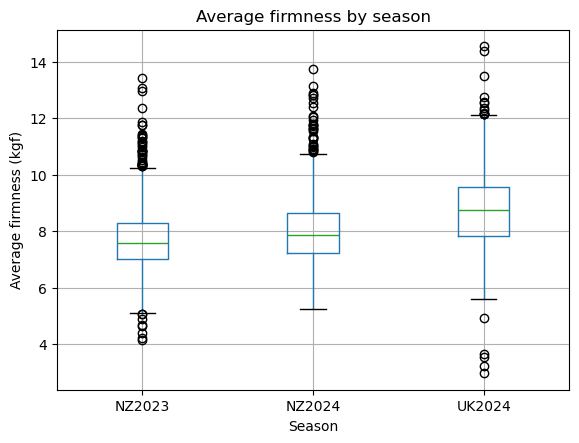

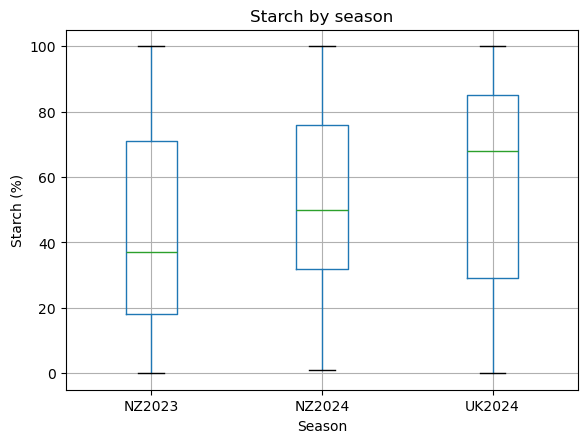

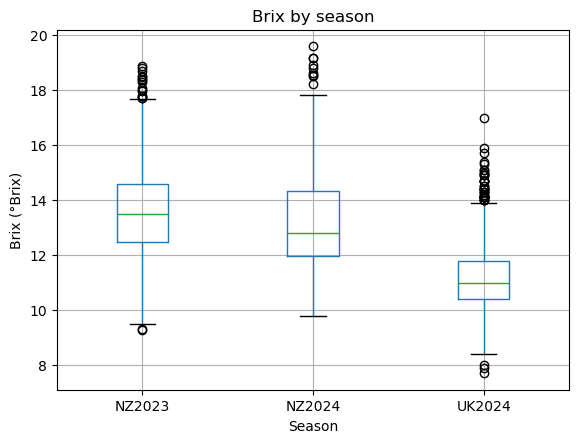

In [ ]:
data_all.boxplot(column ='Avg_firmness', by = 'source')
plt.suptitle('')
plt.ylabel('Average firmness (kgF)')
plt.xlabel('Season')
plt.title('Average firmness by season')
# plt.title('')

data_all.boxplot(column ='Starch', by = 'source')
plt.suptitle('')
plt.ylabel('Starch (%)')
plt.xlabel('Season')
plt.title('Starch by season')
# plt.title('')

data_all.boxplot(column ='Brix', by = 'source')
plt.suptitle('')
plt.ylabel('Brix (°Brix)')
plt.xlabel('Season')
plt.title('Brix by season')
# plt.title('')

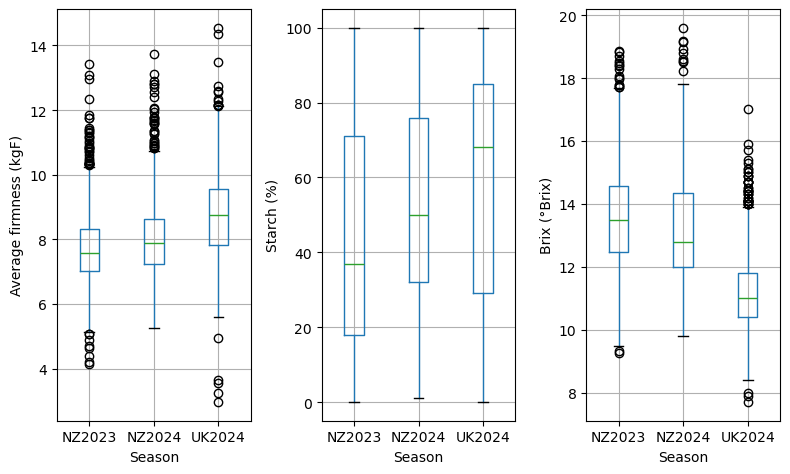

In [40]:
import matplotlib.pyplot as plt

# Create a figure with 3 subplots in 1 row
fig, axes = plt.subplots(1, 3, figsize=(8, 5))

# Plot Avg_firmness
data_all.boxplot(column='Avg_firmness', by='source', ax=axes[0])
# axes[0].set_title('Average firmness by season')
axes[0].set_title('')
axes[0].set_xlabel('Season')
axes[0].set_ylabel('Average firmness (kgF)')

# Plot Starch
data_all.boxplot(column='Starch', by='source', ax=axes[1])
# axes[1].set_title('Starch by season')
axes[1].set_title('')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Starch (%)')

# Plot Brix
data_all.boxplot(column='Brix', by='source', ax=axes[2])
# axes[2].set_title('Brix by season')
axes[2].set_title('')
axes[2].set_xlabel('Season')
axes[2].set_ylabel('Brix (°Brix)')

# Remove the default super title
plt.suptitle('')

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()


In [ ]:
# Generate table of stats
